# How To Run This Notebook

This notebook reproduces the plots and statistics for the Assessment-Loop paper data.

Set up Python environment
Use Python 3.10+ (recommended), then install dependencies:

```bash
pip install pandas matplotlib seaborn numpy scipy statsmodels jupyter
```

## Notes
- If imports fail, re-run the install command and restart the kernel.
- The notebook uses relative paths, so running it from this folder is important.

<!-- # Pre Proccess -->

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


user_question_mapping = {
    'ES_understandable': "The explanations of the agent's paths were clear and easy to understand",
    'ES_overwhelming': "The explanations felt too detailed and overwhelming",
    'ES_feedback_related': "The explanations helped me see how my feedback changed the agent's behavior",
    'ES_helpful': "The visual demonstrations of policy changes helped me understand the differences between agents",
    'ES_improvement': "My feedback helped improve the agent's performance",
    'ES_combined': "Combined score of the explanations' satisfaction",
    "ai:": "How familiar are you with Artificial Intelligence?",
    "AI_1": "I believe AI will improve my life",
    "AI_2": "I believe that AI will improve my work",
    "AI_3": "I think I will use AI technology in the future",
    "AI_4": "I think AI technology is a threat to humans",
    "AI_5": "I think AI technology is positive for humanity",
}


minigrid_models_mean_scores = {6: ('NoRedLH1_0612', 10.87),
                                5: ('AllColorsLH_0617', 9.39),
                                4: ('OnlyBlueLH_0706', 8.84),
                                3: ('OnlyBlueLL_0625', 7.49),
                                2: ('AllColorsLL1_0526', 6.48),
                                1: ('OnlyGreenLL_0429', 1.88)}

fruitbot_models_mean_scores = {'1': 2.505, 
                               '2': 1.19, 
                               '3': 4.4875, 
                               '4': 5.74, 
                               '5': 6.475, 
                               '6': 7.895}

user_results = pd.read_csv("user_results_compact.csv")
choices_results = pd.read_csv("choices_results_compact.csv")

In [2]:
user_results['environment'].value_counts()

environment
MiniGrid    280
FruitBot    214
Name: count, dtype: int64

In [3]:
choices_results['group_label'].value_counts()

group_label
Random              446
Control             423
Salient-Contrast    418
Same                406
Name: count, dtype: int64

In [4]:
user_results['group_label'].value_counts()

group_label
Salient-Contrast    129
Random              126
Control             122
Same                117
Name: count, dtype: int64

In [5]:
# age and gender distribution
df = user_results[user_results['environment'] == 'FruitBot']
print(f"gender distribution for FruitBot: {df['gender'].value_counts()}")
print(f"age distribution for FruitBot: {df['age'].describe()}")

gender distribution for FruitBot: gender
1    110
0    102
3      2
Name: count, dtype: int64
age distribution for FruitBot: count    214.000000
mean      37.383178
std       10.993933
min       18.000000
25%       29.000000
50%       36.000000
75%       44.000000
max       67.000000
Name: age, dtype: float64


In [6]:
user_results.columns

Index(['user_id', 'group_label', 'environment', 'number_of_choices', 'age',
       'gender', 'education', 'familiar_with_AI', 'final_agent_rank',
       'final_agent_mean_score', 'mean_good_choice_local',
       'mean_good_choice_global', 'mean_good_choice_demo', 'AI_1', 'AI_2',
       'AI_3', 'AI_4', 'AI_5', 'evaluate_final_agent', 'ES_understandable',
       'ES_overwhelming', 'ES_feedback_related', 'ES_helpful',
       'ES_improvement', 'ES_combined'],
      dtype='object')

In [7]:
choices_results.columns

Index(['user_id', 'environment', 'group_label', 'prev_agent', 'updated_agent',
       'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score', 'choice',
       'good_choice_global', 'good_choice_local', 'choice_time',
       'good_choice_demo', 'prev_agent_demo_score', 'update_agent_demo_score',
       'improved_from_prev_feedback', 'improved_from_prev_mean',
       'feedback_count'],
      dtype='object')

<!-- # Plotting -->

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu, f_oneway, kruskal
import itertools, warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [9]:
# helper functions: plot_barplot, mannwhitneyu_test, anova_test

colors_palette = ["#686a6b", '#e74c3c', '#2ecc71', '#f39c12',]
group_names = ['Control', 'Random', 'Same', 'Salient-Contrast']
envs = ['MiniGrid', 'FruitBot']
out_dir = 'paper_figures_pdf'

# Hatch textures keep bars distinguishable when the figure is printed on a
# monochrome printer / converted to grayscale (TiiS legibility requirement).
# Fixed per-condition mapping so a given texture always means the same group
# across every figure in the paper.
condition_hatches = {
    'Control': '',
    'Random': '///',
    'Same': '...',
    'Salient-Contrast': 'xxx',
}
# Fallback texture cycle (container order) for hues that are not experimental
# conditions, e.g. the final-agent rank in the delegation plot.
hatch_cycle = ['', '///', '...', 'xxx', '\\\\\\', 'ooo', '++', '--']
plt.rcParams['hatch.linewidth'] = 0.8


def apply_bar_hatches(ax, hatch_lookup=None):
    """Give each hue its own hatch + black edge so bars stay distinct in grayscale.

    ``hatch_lookup`` may be a dict (hue label -> hatch); labels missing from it
    fall back to the position-based ``hatch_cycle``. Pass ``None`` to use the
    cycle for every hue. Returns ``(handles, labels, used_hatches)`` so callers
    can rebuild a legend whose swatches carry the same textures.
    """
    handles, labels = ax.get_legend_handles_labels()
    used_hatches = {}
    for i, container in enumerate(ax.containers):
        label = labels[i] if i < len(labels) else None
        if isinstance(hatch_lookup, dict) and label in hatch_lookup:
            hatch = hatch_lookup[label]
        else:
            hatch = hatch_cycle[i % len(hatch_cycle)]
        used_hatches[label] = hatch
        for bar in container:
            bar.set_hatch(hatch)
            bar.set_edgecolor('black')
            bar.set_linewidth(0.6)
    return handles, labels, used_hatches


def style_legend_handle(handle, hatch):
    """Match a legend swatch to its bar (texture + black edge)."""
    handle.set_hatch(hatch)
    handle.set_edgecolor('black')
    handle.set_linewidth(0.6)
    return handle


def plot_barplot(df, x_col, y_col, hue=None, x_val_names=None,
                 figsize=(6, 5), estimator=lambda x: np.mean(x) * 100, errorbar=('ci', 95),
                 palette=None, x_label='Group', y_label='%', order=None,
                 title=None, save_path=None, hue_order=None):
    if order is None:
        order = sorted(list(df[x_col].unique()))
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=df, x=x_col, y=y_col, hue=hue, hue_order=hue_order, estimator=estimator,
                     errorbar=errorbar, palette=palette, order=order)

    x_val_names = x_val_names or [str(l) for l in order]
    ax.set_xticklabels(x_val_names, rotation=(40 if len(x_val_names[0]) > 15 else 0),
                       ha=('right' if len(x_val_names[0]) > 15 else 'center'), fontsize=13)
    if x_label: plt.xlabel(x_label, fontsize=14)
    if y_label: plt.ylabel(y_label, fontsize=14)
    plt.yticks(fontsize=13)
    if hue:
        # Grayscale-safe hatch textures (fixed per condition) applied to the bars.
        handles, labels, used_hatches = apply_bar_hatches(ax, condition_hatches)
        desired_order = hue_order if hue_order is not None else labels
        legend_handles = [
            style_legend_handle(handles[labels.index(label)], used_hatches.get(label, ''))
            for label in desired_order if label in labels
        ]
        ax.legend(handles=legend_handles, fontsize=11, loc='lower right')
    else:
        # No hue: give each x-category bar its own texture.
        for container in ax.containers:
            for bar, hatch in zip(container, hatch_cycle):
                bar.set_hatch(hatch)
                bar.set_edgecolor('black')
                bar.set_linewidth(0.6)
    if title:
        plt.title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(f"{out_dir}/{save_path}", bbox_inches='tight')

    # Print the exact values plotted in each bar.
    def _apply_estimator(series):
        if callable(estimator):
            return estimator(series)
        if isinstance(estimator, str):
            method_name = {
                'mean': 'mean',
                'median': 'median',
                'sum': 'sum',
                'count': 'count',
                'min': 'min',
                'max': 'max',
            }.get(estimator.lower())
            if method_name is not None:
                return getattr(series, method_name)()
        return series.mean()

    if hue:
        plot_values = (
            df.groupby([x_col, hue])[y_col]
            .apply(_apply_estimator)
            .reset_index(name='plot_value')
            .pivot(index=x_col, columns=hue, values='plot_value')
        )
        plot_values = plot_values.reindex(index=order)
        if hue_order is not None:
            plot_values = plot_values.reindex(columns=hue_order)
    else:
        plot_values = df.groupby(x_col)[y_col].apply(_apply_estimator).rename('plot_value')
        plot_values = plot_values.reindex(order)

    print('\nPlot values:')
    print(plot_values.round(3).to_string())

    plt.show()

def mannwhitneyu_test(df, y_col, x_col, test_type='two-sided'):
    levels = sorted(df[x_col].unique())
    rows = []
    for a, b in itertools.combinations(levels, 2):
        g1, g2 = df[df[x_col]==a][y_col].dropna(), df[df[x_col]==b][y_col].dropna()
        u, p = mannwhitneyu(g1, g2, alternative=test_type)
        rows.append({'group_1': a, 'group_2': b, 'U': u, 'p': round(p, 4)})
    print(pd.DataFrame(rows).to_string(index=False))

def anova_test(df, y_col, x_col):
    groups = [g[y_col].dropna().values for _, g in df.groupby(x_col)]
    f, pf = f_oneway(*groups)
    h, pk = kruskal(*groups)
    print(f"ANOVA F={f:.4f}, p={pf:.4f}  |  Kruskal-Wallis H={h:.4f}, p={pk:.4f}")

<!-- ## Correct Choice -->


Plot values:
group_label  Control  Random    Same  Salient-Contrast
environment                                           
FruitBot      68.679  63.400  84.879            68.571
MiniGrid      75.700  65.548  82.097            75.000


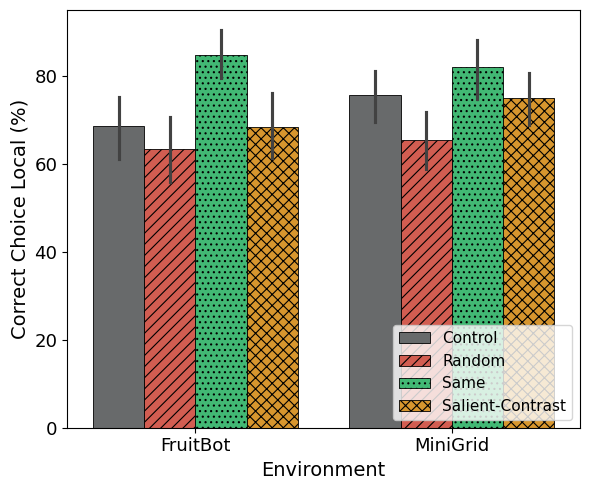

statistic tests for MiniGrid:
ANOVA F=4.4751, p=0.0044  |  Kruskal-Wallis H=15.2891, p=0.0016
         group_1          group_2      U      p
         Control           Random 3178.5 0.9880
         Control Salient-Contrast 2555.0 0.5625
         Control             Same 1773.5 0.0365
          Random Salient-Contrast 2242.0 0.0191
          Random             Same 1510.0 0.0001
Salient-Contrast             Same 1851.5 0.0261
statistic tests for FruitBot:
ANOVA F=7.1260, p=0.0001  |  Kruskal-Wallis H=21.1580, p=0.0001
         group_1          group_2      U      p
         Control           Random 1482.5 0.8543
         Control Salient-Contrast 1520.0 0.5891
         Control             Same  918.5 0.0003
          Random Salient-Contrast 1271.0 0.2047
          Random             Same  738.0 0.0000
Salient-Contrast             Same  993.5 0.0003


In [10]:
# Plot: Correct Choice (Local) by Group
plot_barplot(user_results, 'environment', 'mean_good_choice_local', hue='group_label', hue_order=group_names, x_label='Environment',
             y_label='Correct Choice Local (%)', palette=colors_palette, save_path='correct_choice_local_by_group.pdf')

for env in envs:
    print(f"statistic tests for {env}:")
    anova_test(user_results[user_results['environment'] == env], 'mean_good_choice_local', 'group_label')
    mannwhitneyu_test(user_results[user_results['environment'] == env], 'mean_good_choice_local', 'group_label', test_type='less')


Plot values:
group_label  Control  Random    Same  Salient-Contrast
environment                                           
FruitBot      72.327  60.933  72.879            86.220
MiniGrid      69.034  67.719  73.817            83.744


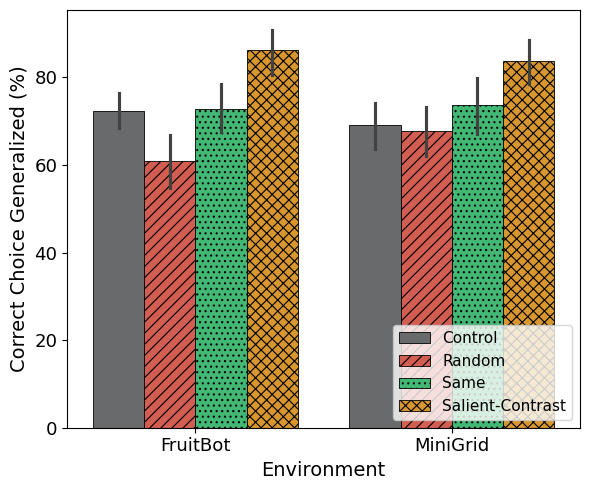

statistic tests for MiniGrid:
         group_1          group_2      U      p
         Control           Random 2620.5 0.9968
         Control Salient-Contrast 1533.5 0.0000
         Control             Same 1795.5 0.1067
          Random Salient-Contrast 1740.5 0.0000
          Random             Same 2017.5 0.1396
Salient-Contrast             Same 2823.5 0.0090
statistic tests for FruitBot:
         group_1          group_2      U      p
         Control           Random 1758.5 0.0037
         Control Salient-Contrast  818.0 0.0000
         Control             Same 1490.0 0.8415
          Random Salient-Contrast  567.5 0.0000
          Random             Same  999.5 0.0146
Salient-Contrast             Same 2095.0 0.0006


In [11]:
# Plot: Correct Choice (Generalized) by Group
plot_barplot(user_results, 'environment', 'mean_good_choice_global', hue='group_label', errorbar=('ci', 95), x_label='Environment', 
             hue_order=group_names, y_label='Correct Choice Generalized (%)', palette=colors_palette, save_path='correct_choice_generalized_by_group.pdf')
for env in envs:
    print(f"statistic tests for {env}:")
    mannwhitneyu_test(user_results[user_results['environment'] == env], 'mean_good_choice_global', 'group_label')

## Correct Choice by update direction

<!-- ## Correct Choice seperated by improve dir -->

In [12]:
# Plot: Correct Choice (Local) by Update Direction -- Same vs Salient-Contrast

def plot_correct_choice_by_update_direction(choices_results, correct_choice_type: str, improved_from_type: str, 
                                            mannwhitneyu_type='two-sided', save_path=None):
    if correct_choice_type not in ['good_choice_local', 'good_choice_global', 'good_choice_demo']:
        print(f"Invalid correct_choice_type: {correct_choice_type}.")
        return
    if improved_from_type not in ['improved_from_prev_feedback', 'improved_from_prev_mean']:
        print(f"Invalid improved_from_type: {improved_from_type}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(7, 5), sharey=True)
    groups_include = ['Same', 'Salient-Contrast']

    for ax, env in zip(axes, envs):
        env_df = choices_results[
            (choices_results['group_label'].isin(groups_include)) &
            (choices_results['environment'] == env)
        ].copy()

        # Print the exact bar values (percent) before plotting.
        bar_values = (
            env_df.groupby([improved_from_type, 'group_label'])[correct_choice_type]
            .mean()
            .mul(100)
            .unstack('group_label')
            .reindex(index=[0, 1], columns=groups_include)
        )
        bar_values.index = ['Negative', 'Positive']
        print(f"\nBar values for {env} ({correct_choice_type}):")
        print(bar_values.round(2).to_string())

        sns.barplot(
            data=env_df,
            x=improved_from_type,
            y=correct_choice_type,
            hue='group_label',
            estimator=lambda x: np.mean(x) * 100,
            errorbar=('ci', 95),
            order=[0, 1],
            hue_order=groups_include,
            palette=colors_palette[4-len(groups_include):4],
            ax=ax,
        )
        # Grayscale-safe hatch textures (same per-condition mapping as the other figures).
        apply_bar_hatches(ax, condition_hatches)
        correct_choice_name = 'Local'
        if correct_choice_type == 'good_choice_global':
            correct_choice_name = 'Generalized'
        ax.set_title(env.capitalize(), fontsize=14)
        ax.set_xlabel('Policy Update', fontsize=14)
        ax.set_ylabel(f'Correct Choice {correct_choice_name} (%)' if ax is axes[0] else '', fontsize=14)
        ax.set_xticklabels(['Negative', 'Positive'], fontsize=13)

        if ax is not axes[0]:
            ax.legend_.remove()

    handles, labels = axes[0].get_legend_handles_labels()
    desired_order = groups_include  # ['Same', 'Salient-Contrast']
    legend_handles = [
        style_legend_handle(handles[labels.index(g)], condition_hatches.get(g, ''))
        for g in desired_order if g in labels
    ]

    axes[0].legend(handles=legend_handles, title='Group', fontsize=13, title_fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(f"{out_dir}/{save_path}.pdf", bbox_inches='tight')
    plt.show()

    # Per-participant per-direction aggregation:
    # For each participant, compute mean correct choice within each direction (0/1),
    # then run Mann-Whitney between groups within each direction stratum.
    for env in envs:
        env_df = choices_results[
            (choices_results['group_label'].isin(groups_include)) &
            (choices_results['environment'] == env)
        ].copy()

        print(f"--- Per-participant by-direction Mann-Whitney tests for {env} ({correct_choice_type}, {improved_from_type}) ---")

        all_users = set(env_df['user_id'].dropna().unique())

        for update_value, update_name in [(1, 'Positive'), (0, 'Negative')]:
            direction_df = env_df[env_df[improved_from_type] == update_value].copy()

            participant_means = (
                direction_df
                .groupby(['user_id', 'group_label'], as_index=False)[correct_choice_type]
                .mean()
                .rename(columns={correct_choice_type: 'participant_direction_mean'})
            )

            included_users = set(participant_means['user_id'].unique())
            dropped_count = len(all_users - included_users)

            print(f"--- {update_name} updates ---")
            print(f"Participants included in this stratum: {len(included_users)}")
            print(f"Participants dropped (no rounds in this direction): {dropped_count}")
            print("Participants per group:")
            print(participant_means['group_label'].value_counts().to_string())

            mannwhitneyu_test(
                participant_means,
                y_col='participant_direction_mean',
                x_col='group_label',
                test_type=mannwhitneyu_type,
            )


Bar values for MiniGrid (good_choice_local):
group_label   Same  Salient-Contrast
Negative     59.26             59.26
Positive     89.80             77.71

Bar values for FruitBot (good_choice_local):
group_label   Same  Salient-Contrast
Negative     79.55             60.00
Positive     89.74             75.93


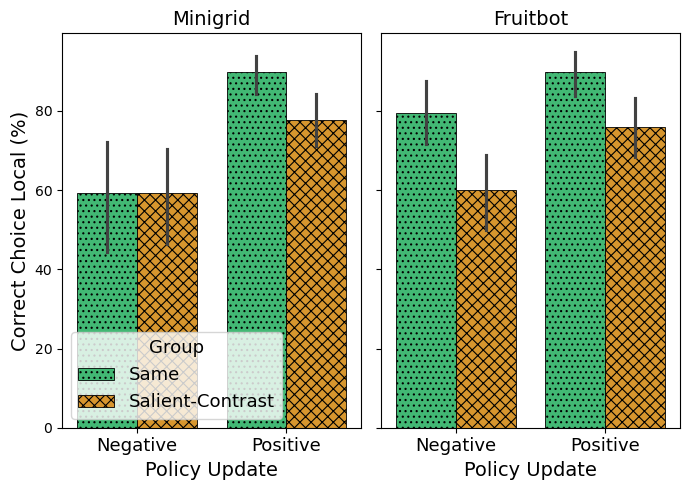

--- Per-participant by-direction Mann-Whitney tests for MiniGrid (good_choice_local, improved_from_prev_feedback) ---
--- Positive updates ---
Participants included in this stratum: 134
Participants dropped (no rounds in this direction): 1
Participants per group:
group_label
Salient-Contrast    72
Same                62
         group_1 group_2      U      p
Salient-Contrast    Same 1829.5 0.0145
--- Negative updates ---
Participants included in this stratum: 78
Participants dropped (no rounds in this direction): 57
Participants per group:
group_label
Salient-Contrast    40
Same                38
         group_1 group_2     U      p
Salient-Contrast    Same 750.0 0.4583
--- Per-participant by-direction Mann-Whitney tests for FruitBot (good_choice_local, improved_from_prev_feedback) ---
--- Positive updates ---
Participants included in this stratum: 103
Participants dropped (no rounds in this direction): 8
Participants per group:
group_label
Same                52
Salient-Contrast    5

In [13]:
plot_correct_choice_by_update_direction(choices_results, 'good_choice_local', 'improved_from_prev_feedback', 
                                        mannwhitneyu_type='less', save_path='correct_choice_local_by_update_direction')


Bar values for MiniGrid (good_choice_global):
group_label   Same  Salient-Contrast
Negative     42.03             72.73
Positive     86.36             88.81

Bar values for FruitBot (good_choice_global):
group_label   Same  Salient-Contrast
Negative     52.31             72.37
Positive     78.57             92.62


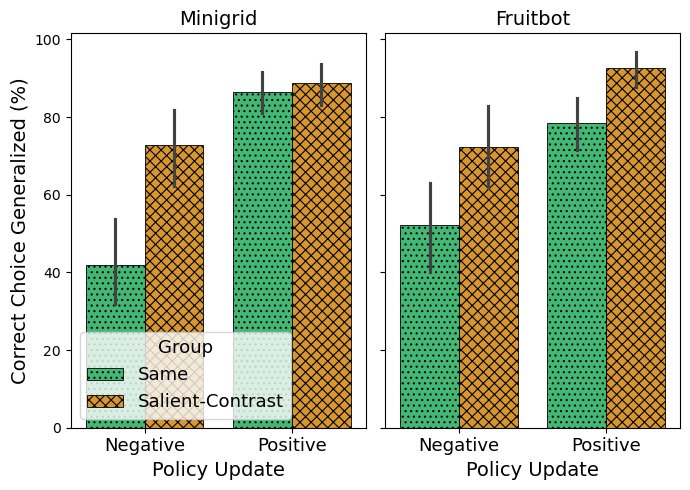

--- Per-participant by-direction Mann-Whitney tests for MiniGrid (good_choice_global, improved_from_prev_mean) ---
--- Positive updates ---
Participants included in this stratum: 135
Participants dropped (no rounds in this direction): 0
Participants per group:
group_label
Salient-Contrast    73
Same                62
         group_1 group_2      U      p
Salient-Contrast    Same 2366.5 0.2706
--- Negative updates ---
Participants included in this stratum: 93
Participants dropped (no rounds in this direction): 42
Participants per group:
group_label
Salient-Contrast    49
Same                44
         group_1 group_2      U      p
Salient-Contrast    Same 1408.0 0.0032
--- Per-participant by-direction Mann-Whitney tests for FruitBot (good_choice_global, improved_from_prev_mean) ---
--- Positive updates ---
Participants included in this stratum: 110
Participants dropped (no rounds in this direction): 1
Participants per group:
group_label
Same                55
Salient-Contrast    55
  

In [14]:
plot_correct_choice_by_update_direction(choices_results, 'good_choice_global', 'improved_from_prev_mean', 
                                        mannwhitneyu_type='greater', save_path='correct_choice_generalized_by_update_direction')

## Explanation Satisfactions

<!-- ## Agent Rating -->

In [15]:
user_question_mapping

{'ES_understandable': "The explanations of the agent's paths were clear and easy to understand",
 'ES_overwhelming': 'The explanations felt too detailed and overwhelming',
 'ES_feedback_related': "The explanations helped me see how my feedback changed the agent's behavior",
 'ES_helpful': 'The visual demonstrations of policy changes helped me understand the differences between agents',
 'ES_improvement': "My feedback helped improve the agent's performance",
 'ES_combined': "Combined score of the explanations' satisfaction",
 'ai:': 'How familiar are you with Artificial Intelligence?',
 'AI_1': 'I believe AI will improve my life',
 'AI_2': 'I believe that AI will improve my work',
 'AI_3': 'I think I will use AI technology in the future',
 'AI_4': 'I think AI technology is a threat to humans',
 'AI_5': 'I think AI technology is positive for humanity'}

The explanations helped me see how my feedback changed the agent's behavior

Plot values:
group_label  Random   Same  Salient-Contrast
environment                                 
FruitBot      5.020  5.109             5.018
MiniGrid      4.474  5.065             4.548


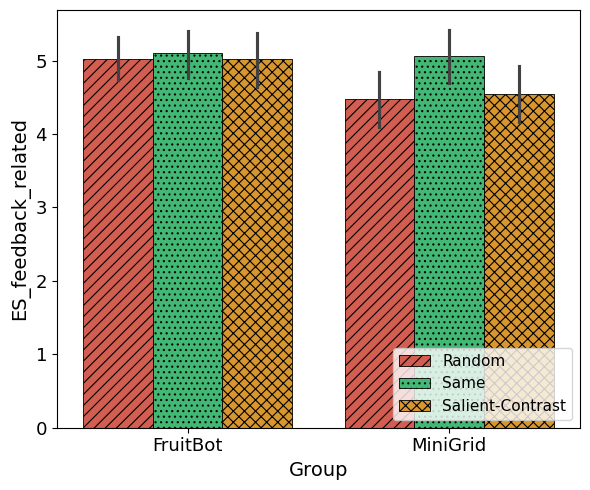

statistic tests for MiniGrid on ES_feedback_related:
         group_1          group_2      U      p
          Random Salient-Contrast 2766.5 0.9784
          Random             Same 1890.5 0.0419
Salient-Contrast             Same 1810.5 0.0416
statistic tests for FruitBot on ES_feedback_related:
         group_1          group_2      U      p
          Random Salient-Contrast 1336.5 0.6779
          Random             Same 1237.0 0.3512
Salient-Contrast             Same 1488.5 0.7538

--------------------------------------------------

The explanations of the agent's paths were clear and easy to understand

Plot values:
group_label  Random   Same  Salient-Contrast
environment                                 
FruitBot      5.080  5.327             5.250
MiniGrid      4.632  5.000             5.137


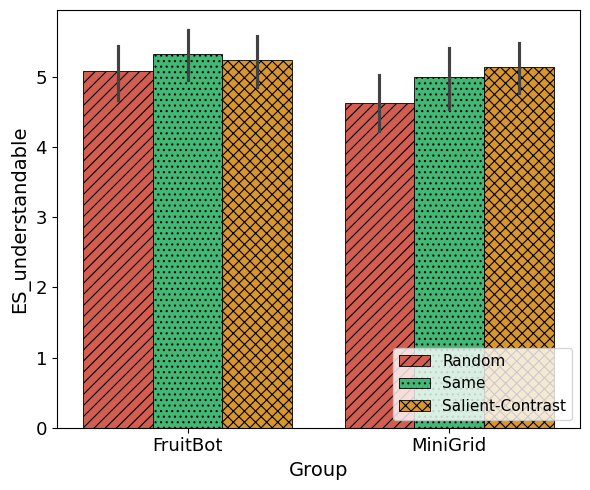

statistic tests for MiniGrid on ES_understandable:
         group_1          group_2      U      p
          Random Salient-Contrast 2368.5 0.1151
          Random             Same 2077.5 0.2225
Salient-Contrast             Same 2313.0 0.8226
statistic tests for FruitBot on ES_understandable:
         group_1          group_2      U      p
          Random Salient-Contrast 1346.0 0.7216
          Random             Same 1295.0 0.5919
Salient-Contrast             Same 1508.0 0.8461

--------------------------------------------------

The explanations felt too detailed and overwhelming

Plot values:
group_label  Random   Same  Salient-Contrast
environment                                 
FruitBot      3.620  3.618             3.536
MiniGrid      3.566  3.516             3.342


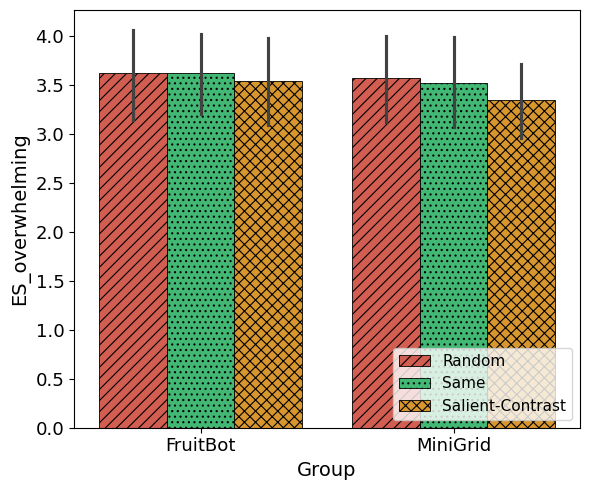

statistic tests for MiniGrid on ES_overwhelming:
         group_1          group_2      U      p
          Random Salient-Contrast 2936.5 0.5325
          Random             Same 2381.5 0.9135
Salient-Contrast             Same 2136.0 0.5705
statistic tests for FruitBot on ES_overwhelming:
         group_1          group_2      U      p
          Random Salient-Contrast 1423.0 0.8846
          Random             Same 1338.0 0.8111
Salient-Contrast             Same 1480.0 0.7212

--------------------------------------------------

The visual demonstrations of policy changes helped me understand the differences between agents

Plot values:
group_label  Random   Same  Salient-Contrast
environment                                 
FruitBot      5.400  5.564             5.375
MiniGrid      4.895  5.371             5.247


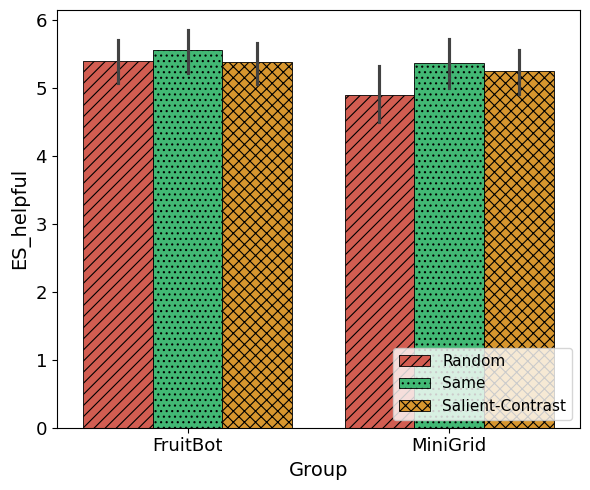

statistic tests for MiniGrid on ES_helpful:
         group_1          group_2      U      p
          Random Salient-Contrast 2558.5 0.4024
          Random             Same 1962.0 0.0829
Salient-Contrast             Same 2060.0 0.3581
statistic tests for FruitBot on ES_helpful:
         group_1          group_2      U      p
          Random Salient-Contrast 1393.5 0.9685
          Random             Same 1211.5 0.2721
Salient-Contrast             Same 1354.0 0.2416

--------------------------------------------------

Combined score of the explanations' satisfaction

Plot values:
group_label  Random   Same  Salient-Contrast
environment                                 
FruitBot      4.320  4.491             4.429
MiniGrid      3.934  4.339             4.233


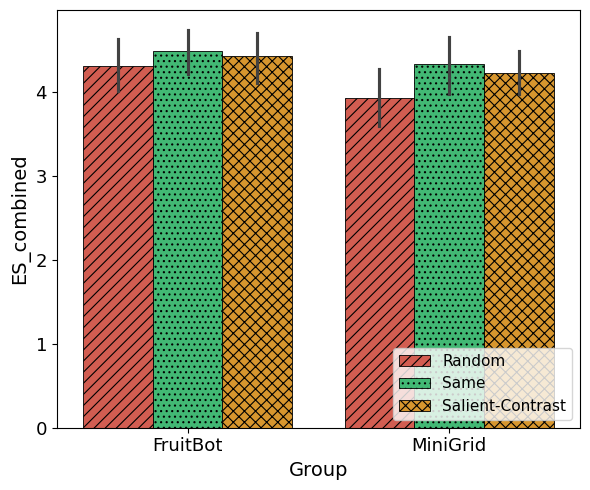

statistic tests for MiniGrid on ES_combined:
         group_1          group_2      U      p
          Random Salient-Contrast 2542.0 0.3664
          Random             Same 1993.0 0.1092
Salient-Contrast             Same 2062.0 0.3609
statistic tests for FruitBot on ES_combined:
         group_1          group_2      U      p
          Random Salient-Contrast 1335.5 0.6729
          Random             Same 1268.5 0.4738
Salient-Contrast             Same 1491.5 0.7663

--------------------------------------------------



In [31]:
# user satisfaction with the feedback and explanations
satisfaction_list = ['ES_feedback_related', 'ES_understandable', 'ES_overwhelming', 'ES_helpful', 'ES_combined']
for y_column in satisfaction_list[:]:
    print(user_question_mapping[y_column])
    user_results_p = user_results[user_results[y_column].notnull()].copy()
    user_results_p[y_column] = user_results_p[y_column].astype(int)
    plot_barplot(user_results_p, 'environment', y_column,  #y_label='Explanation Satisfaction (avg)',
                y_label=y_column, palette=colors_palette[1:], hue='group_label', hue_order=group_names[1:],
                estimator=lambda x: np.mean(x), save_path=f'{y_column}_by_group.pdf')
    for env in envs:
        print(f"statistic tests for {env} on {y_column}:")
        mannwhitneyu_test(user_results_p[user_results_p['environment'] == env], y_column, 'group_label', test_type='two-sided')
    print("\n" + "-"*50 + "\n")

In [17]:
# Internal consistency of satisfaction self-report items (Cronbach's alpha) by environment
alpha_items = ['ES_feedback_related', 'ES_understandable', 'ES_helpful']

alpha_rows = []
for env in envs:
    df_env = user_results[user_results['environment'] == env].copy()

    # Build scale with reverse-scored ES_overwhelming.
    scale_df = df_env[alpha_items + ['ES_overwhelming']].copy()
    scale_df['ES_overwhelming_rev'] = 7 - pd.to_numeric(scale_df['ES_overwhelming'], errors='coerce')
    scale_df = scale_df[alpha_items + ['ES_overwhelming_rev']].apply(pd.to_numeric, errors='coerce')

    # Listwise deletion for alpha computation.
    scale_df = scale_df.dropna()
    n = len(scale_df)
    k = scale_df.shape[1]

    if n < 2 or k < 2:
        alpha = np.nan
    else:
        item_vars = scale_df.var(axis=0, ddof=1)
        total_var = scale_df.sum(axis=1).var(ddof=1)
        alpha = (k / (k - 1)) * (1 - (item_vars.sum() / total_var)) if total_var > 0 else np.nan

    alpha_rows.append({'environment': env, 'n_complete': n, 'k_items': k, 'cronbach_alpha': alpha})

alpha_results = pd.DataFrame(alpha_rows)
print('Cronbach alpha for satisfaction items by environment (ES_overwhelming reverse-scored):')
display(alpha_results.round(4))

Cronbach alpha for satisfaction items by environment (ES_overwhelming reverse-scored):


,environment,n_complete,k_items,cronbach_alpha
0,MiniGrid,211,4,0.8252
1,FruitBot,161,4,0.7330


## Choice Time

<!-- ## Choice Time -->


Plot values:
group_label  Random    Same  Salient-Contrast
environment                                  
FruitBot     17.703  15.827            16.161
MiniGrid     26.115  26.669            27.167


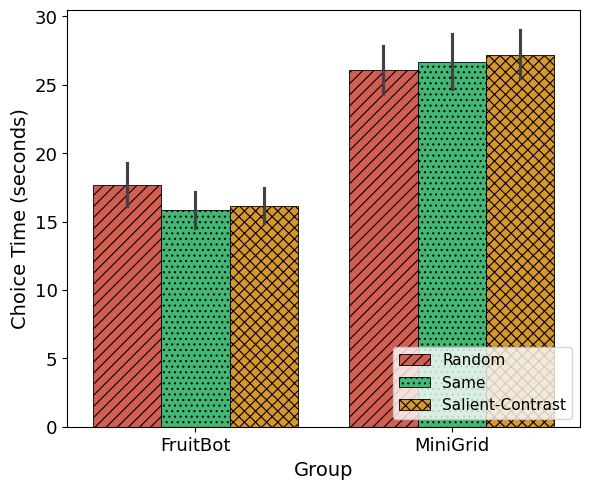

statistic tests for MiniGrid:
ANOVA F=0.3404, p=0.7116  |  Kruskal-Wallis H=1.3155, p=0.5180
         group_1          group_2       U      p
          Random Salient-Contrast 22373.0 0.2627
          Random             Same 18741.5 0.5043
Salient-Contrast             Same 17278.5 0.6737
statistic tests for FruitBot:
ANOVA F=1.7603, p=0.1729  |  Kruskal-Wallis H=1.9088, p=0.3850
         group_1          group_2       U      p
          Random Salient-Contrast 17237.0 0.5254
          Random             Same 17800.0 0.1685
Salient-Contrast             Same 19261.5 0.4452


In [18]:
plot_df = choices_results[(choices_results['choice_time'] < 60) & (choices_results['choice_time'] > 0)]  # Filter out extreme outliers for better visualization
if plot_df.empty:
    print("No valid choice_time data to plot.")
else:
    plot_barplot(plot_df, 'environment', 'choice_time', y_label='Choice Time (seconds)', 
                 hue='group_label', palette=colors_palette[1:], hue_order=group_names[1:],
                 estimator='mean')
    for env in envs:
        print(f"statistic tests for {env}:")
        anova_test(plot_df[plot_df['environment'] == env], 'choice_time', 'group_label')
        mannwhitneyu_test(plot_df[plot_df['environment'] == env], 'choice_time', 'group_label')

## Final Agent

<!-- ## Delegation - Trust the Agent -->

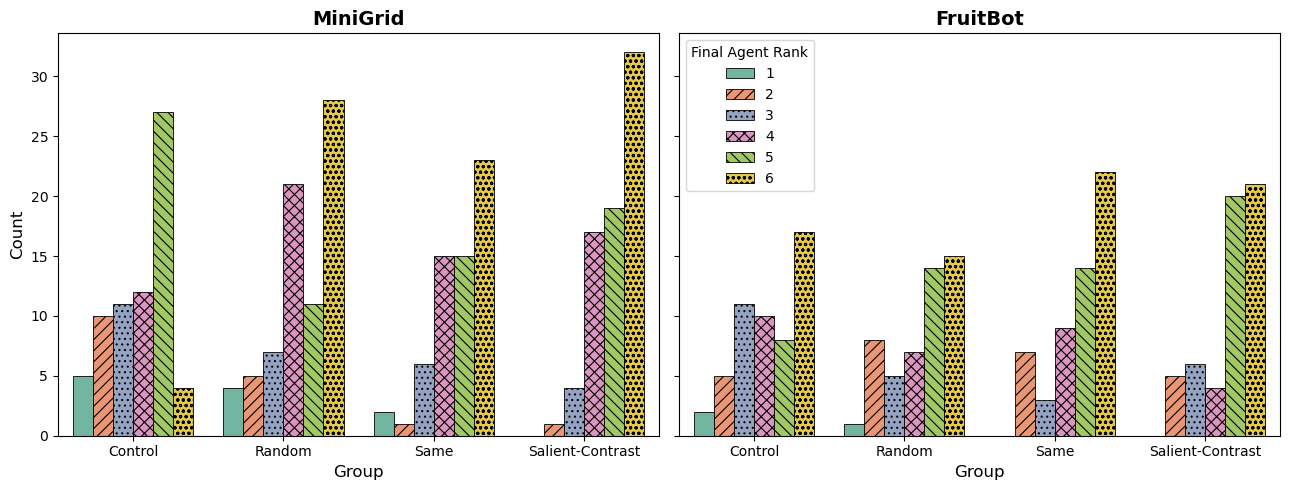

In [19]:
# Plot: Count of Final Agent by Group (side-by-side: Minigrid and Fruitbot)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, env in zip(axes, envs):
    grouped = (
        user_results[user_results['environment'] == env]
        .groupby(['group_label', 'final_agent_rank'])
        .size()
        .reset_index(name='count')
    )

    final_agent_levels = sorted(grouped['final_agent_rank'].dropna().unique())

    sns.barplot(
        data=grouped,
        x='group_label',
        y='count',
        hue='final_agent_rank',
        hue_order=final_agent_levels,
        order=group_names,
        palette='Set2',
        ax=ax
    )

    # Grayscale-safe hatch textures: one per final-agent rank (position-based cycle).
    apply_bar_hatches(ax)

    ax.set_title(env, fontsize=14, fontweight='bold')
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('Count' if env == 'MiniGrid' else '', fontsize=12)
    ax.tick_params(axis='x', rotation=0)

# Keep legend only on Fruitbot (right panel), upper-right
axes[0].legend_.remove()
handles, labels = axes[1].get_legend_handles_labels()
for handle, hatch in zip(handles, hatch_cycle):
    style_legend_handle(handle, hatch)
axes[1].legend(handles=handles, labels=labels, title='Final Agent Rank', loc='upper left')

plt.tight_layout()
plt.savefig(f"{out_dir}/count_of_final_agent_by_group.pdf", bbox_inches='tight')
plt.show()


Plot values:
group_label  Control  Random   Same  Salient-Contrast
environment                                          
FruitBot       5.805   5.858  6.309             6.388
MiniGrid       8.111   9.022  9.333             9.767


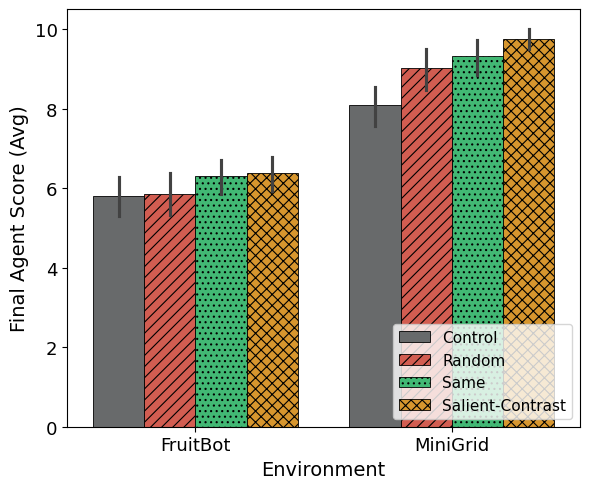

statistic tests for MiniGrid:
ANOVA F=10.0882, p=0.0000  |  Kruskal-Wallis H=27.9999, p=0.0000
         group_1          group_2      U      p
         Control           Random 1926.0 0.0024
         Control Salient-Contrast 1278.5 0.0000
         Control             Same 1346.5 0.0001
          Random Salient-Contrast 2249.5 0.0185
          Random             Same 2165.5 0.1988
Salient-Contrast             Same 2521.5 0.8856
statistic tests for FruitBot:
ANOVA F=1.4569, p=0.2274  |  Kruskal-Wallis H=4.5913, p=0.2043
         group_1          group_2      U      p
         Control           Random 1274.0 0.3662
         Control Salient-Contrast 1204.0 0.0398
         Control             Same 1212.0 0.0598
          Random Salient-Contrast 1183.5 0.0775
          Random             Same 1196.0 0.1176
Salient-Contrast             Same 1570.5 0.5760


In [27]:
# Final agent score by group

plot_barplot(user_results, 'environment', 'final_agent_mean_score', hue='group_label', hue_order=group_names, 
             x_label='Environment',
            y_label='Final Agent Score (Avg)',
            estimator = 'mean',
        palette=colors_palette,
        save_path='final_agent_score_by_group.pdf')

# statistic tests for final agent score by group
for env in envs:
    print(f"statistic tests for {env}:")
    anova_test(user_results[user_results['environment'] == env], 'final_agent_mean_score', 'group_label')
    mannwhitneyu_test(user_results[user_results['environment'] == env], 'final_agent_mean_score', 'group_label', test_type='less')


Plot values:
group_label  Control  Random   Same  Salient-Contrast
environment                                          
FruitBot       4.019   4.500  4.709             4.464
MiniGrid       3.087   3.316  3.129             3.644


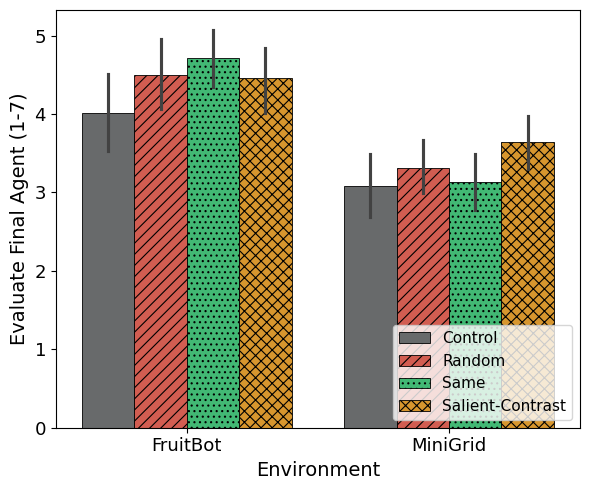

statistic tests for MiniGrid on evaluate_final_agent:
ANOVA F=1.8130, p=0.1450  |  Kruskal-Wallis H=6.2141, p=0.1016
         group_1          group_2      U      p
         Control           Random 2345.5 0.2614
         Control Salient-Contrast 1995.5 0.0289
         Control             Same 2056.5 0.6975
          Random Salient-Contrast 2434.0 0.1855
          Random             Same 2526.0 0.4545
Salient-Contrast             Same 2693.0 0.0516
statistic tests for FruitBot on evaluate_final_agent:
ANOVA F=1.7869, p=0.1507  |  Kruskal-Wallis H=4.3338, p=0.2276
         group_1          group_2      U      p
         Control           Random 1124.5 0.1794
         Control Salient-Contrast 1271.0 0.1895
         Control             Same 1140.5 0.0474
          Random Salient-Contrast 1410.5 0.9484
          Random             Same 1273.0 0.5050
Salient-Contrast             Same 1405.5 0.4178


In [21]:
# User Evaluate final agent by group
df = user_results[user_results['final_agent_rank'] > 0].copy()
plot_barplot(df, 'environment', 'evaluate_final_agent', hue='group_label', hue_order=group_names,
              x_label='Environment', y_label='Evaluate Final Agent (1-7)', palette=colors_palette, estimator='mean')
for env in envs:
    print(f"statistic tests for {env} on evaluate_final_agent:")
    anova_test(df[df['environment'] == env], 'evaluate_final_agent', 'group_label')
    mannwhitneyu_test(df[df['environment'] == env], 'evaluate_final_agent', 'group_label', test_type='two-sided')